In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ucimachinelearning/deep-fake-detection-cropped-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'deep-fake-detection-cropped-dataset' dataset.
Path to dataset files: /kaggle/input/deep-fake-detection-cropped-dataset


In [2]:
import os
from pathlib import Path

# Convert Kaggle download path into a Path object
data_root = Path(path)

print("Dataset root:", data_root)

# View all folders and first few files
for root, dirs, files in os.walk(data_root):
    level = root.replace(str(data_root), "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{Path(root).name}/")

    for file in files[:3]:
        print(f"{indent}    {file}")

Dataset root: /kaggle/input/deep-fake-detection-cropped-dataset
deep-fake-detection-cropped-dataset/
    DFDC_Dataset/
        Fake/
            cmchigmmtb.mp4
            bateuibxti.mp4
            bcavrprfct.mp4
        Real/
            iggixplyqf.mp4
            mppjpwwcom.mp4
            fvcqerfgfa.mp4


In [3]:
# Locate real and fake video folders automatically
fake_folder = next(data_root.rglob("Fake"))
real_folder = next(data_root.rglob("Real"))

fake_videos = list(fake_folder.glob("*.mp4"))
real_videos = list(real_folder.glob("*.mp4"))

print("Fake video folder:", fake_folder)
print("Real video folder:", real_folder)
print("Number of fake videos:", len(fake_videos))
print("Number of real videos:", len(real_videos))

Fake video folder: /kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Fake
Real video folder: /kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Real
Number of fake videos: 1566
Number of real videos: 1727


In [4]:
# Show example video file paths
print("Example fake videos:")
for video in fake_videos[:5]:
    print(video)

print("\nExample real videos:")
for video in real_videos[:5]:
    print(video)

Example fake videos:
/kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Fake/cmchigmmtb.mp4
/kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Fake/bateuibxti.mp4
/kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Fake/bcavrprfct.mp4
/kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Fake/cbfbxgvcpd.mp4
/kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Fake/dtyxicmtwr.mp4

Example real videos:
/kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Real/iggixplyqf.mp4
/kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Real/mppjpwwcom.mp4
/kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Real/fvcqerfgfa.mp4
/kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Real/jjycletzyl.mp4
/kaggle/input/deep-fake-detection-cropped-dataset/DFDC_Dataset/Real/qooxnxqqjb.mp4


In [5]:
# Create output folders for cropped face images
output_root = Path("/content/deepfake_face_images")

real_output = output_root / "real"
fake_output = output_root / "fake"

real_output.mkdir(parents=True, exist_ok=True)
fake_output.mkdir(parents=True, exist_ok=True)

print("Cropped facial images will be saved at:", output_root)

Cropped facial images will be saved at: /content/deepfake_face_images


In [6]:
# Install required packages for video-frame and face extraction
!pip -q install opencv-python tqdm

In [7]:
import cv2
from tqdm import tqdm

# Load pre-trained OpenCV frontal-face detector
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def extract_faces(video_list, output_folder, frame_interval=30, max_videos=250):
    """
    Extracts one frame every 30 frames, detects the main face,
    crops it, and saves it as a JPG image.
    """

    saved_count = 0

    for video_path in tqdm(video_list[:max_videos]):
        cap = cv2.VideoCapture(str(video_path))
        frame_number = 0
        video_name = video_path.stem

        while cap.isOpened():
            success, frame = cap.read()

            if not success:
                break

            if frame_number % frame_interval == 0:
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

                faces = face_detector.detectMultiScale(
                    gray,
                    scaleFactor=1.1,
                    minNeighbors=5,
                    minSize=(60, 60)
                )

                # Use only the first detected face from each selected frame
                if len(faces) > 0:
                    x, y, w, h = faces[0]

                    margin = 20
                    x1 = max(0, x - margin)
                    y1 = max(0, y - margin)
                    x2 = min(frame.shape[1], x + w + margin)
                    y2 = min(frame.shape[0], y + h + margin)

                    face_crop = frame[y1:y2, x1:x2]

                    if face_crop.size > 0:
                        save_name = f"{video_name}_frame_{frame_number}.jpg"
                        save_path = output_folder / save_name

                        cv2.imwrite(str(save_path), face_crop)
                        saved_count += 1

            frame_number += 1

        cap.release()

    return saved_count

In [8]:
import shutil

# Clear output directories to prevent overwriting issues from previous runs
if real_output.exists():
    shutil.rmtree(real_output)
real_output.mkdir(parents=True, exist_ok=True)

if fake_output.exists():
    shutil.rmtree(fake_output)
fake_output.mkdir(parents=True, exist_ok=True)


real_faces_saved = extract_faces(
    real_videos,
    real_output,
    frame_interval=30,
    max_videos=150 # Process more real videos to get around 300 images
)

fake_faces_saved = extract_faces(
    fake_videos,
    fake_output,
    frame_interval=30,
    max_videos=150 # Process more fake videos to get around 300 images
)

print("Real cropped faces saved:", real_faces_saved)
print("Fake cropped faces saved:", fake_faces_saved)

100%|██████████| 150/150 [00:21<00:00,  7.03it/s]

Real cropped faces saved: 145
Fake cropped faces saved: 138


In [9]:
# Confirm final cropped-image dataset
real_images = list(real_output.glob("*.jpg"))
fake_images = list(fake_output.glob("*.jpg"))

print("Total real face images:", len(real_images))
print("Total fake face images:", len(fake_images))

Total real face images: 145
Total fake face images: 138


In [10]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# This must be the same output path used during face extraction
output_root = Path("/content/deepfake_face_images")

# 70% training and 30% remaining data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    output_root,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

remaining_dataset = tf.keras.utils.image_dataset_from_directory(
    output_root,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# Split remaining 30% into 15% validation and 15% test data
total_remaining_batches = tf.data.experimental.cardinality(remaining_dataset)
validation_batches = total_remaining_batches // 2

validation_dataset = remaining_dataset.take(validation_batches)
test_dataset = remaining_dataset.skip(validation_batches)

print("Class names:", train_dataset.class_names)
print("0 = Fake, 1 = Real")

Found 283 files belonging to 2 classes.
Using 199 files for training.
Found 283 files belonging to 2 classes.
Using 84 files for validation.
Class names: ['fake', 'real']
0 = Fake, 1 = Real


# **Create train, validation and test datasets**

In [11]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# This must be the same output path used during face extraction
output_root = Path("/content/deepfake_face_images")

# 70% training and 30% remaining data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    output_root,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

remaining_dataset = tf.keras.utils.image_dataset_from_directory(
    output_root,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# Split remaining 30% into 15% validation and 15% test data
total_remaining_batches = tf.data.experimental.cardinality(remaining_dataset)
validation_batches = total_remaining_batches // 2

validation_dataset = remaining_dataset.take(validation_batches)
test_dataset = remaining_dataset.skip(validation_batches)

print("Class names:", train_dataset.class_names)
print("0 = Fake, 1 = Real")

Found 283 files belonging to 2 classes.
Using 199 files for training.
Found 283 files belonging to 2 classes.
Using 84 files for validation.
Class names: ['fake', 'real']
0 = Fake, 1 = Real


# **Visualise class distribution**

,Class,Number of Images
0,Real,145
1,Fake,138


/tmp/ipykernel_46152/3475380419.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


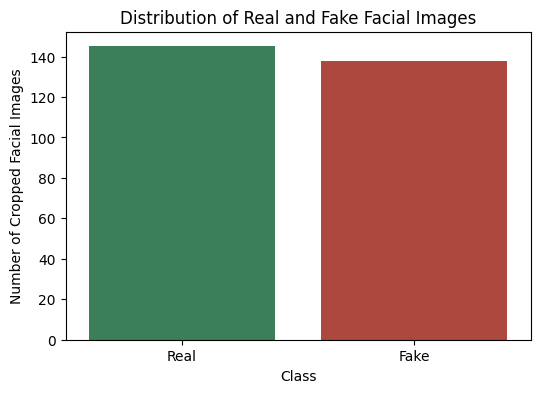

In [12]:
real_count = len(list((output_root / "real").glob("*.jpg")))
fake_count = len(list((output_root / "fake").glob("*.jpg")))

class_distribution = pd.DataFrame({
    "Class": ["Real", "Fake"],
    "Number of Images": [real_count, fake_count]
})

display(class_distribution)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=class_distribution,
    x="Class",
    y="Number of Images",
    palette=["#2E8B57", "#C0392B"]
)
plt.title("Distribution of Real and Fake Facial Images")
plt.ylabel("Number of Cropped Facial Images")
plt.show()

# **Extract image dimensions, aspect ratios and brightness**

In [13]:
import cv2
from tqdm import tqdm

# Create image_df from real_images and fake_images
real_image_df = pd.DataFrame({
    "image_path": [str(p) for p in real_images],
    "class_name": "Real"
})

fake_image_df = pd.DataFrame({
    "image_path": [str(p) for p in fake_images],
    "class_name": "Fake"
})

image_df = pd.concat([real_image_df, fake_image_df], ignore_index=True)

# Use a maximum of 2,000 images for fast EDA.
# Change 2000 to len(image_df) if Colab has sufficient processing capacity.
eda_sample = image_df.sample(
    n=min(2000, len(image_df)),
    random_state=42
).copy()

widths = []
heights = []
brightness_values = []

for image_path in tqdm(eda_sample["image_path"], desc="Extracting image properties"):
    image = cv2.imread(image_path)

    if image is not None:
        height, width = image.shape[:2]
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        widths.append(width)
        heights.append(height)
        brightness_values.append(gray_image.mean())
    else:
        widths.append(np.nan)
        heights.append(np.nan)
        brightness_values.append(np.nan)

eda_sample["width"] = widths
eda_sample["height"] = heights
eda_sample["aspect_ratio"] = eda_sample["width"] / eda_sample["height"]
eda_sample["mean_brightness"] = brightness_values

eda_sample = eda_sample.dropna()

display(eda_sample[[
    "class_name", "width", "height", "aspect_ratio", "mean_brightness"
]].head())

Extracting image properties: 100%|██████████| 283/283 [00:00<00:00, 817.12it/s]


,class_name,width,height,aspect_ratio,mean_brightness
9,Real,112,112,1.000000,15.807318
246,Fake,112,112,1.000000,82.253348
139,Real,112,112,1.000000,20.394930
207,Fake,112,112,1.000000,75.152742
75,Real,112,110,1.018182,95.224432


## **Image-width distribution**

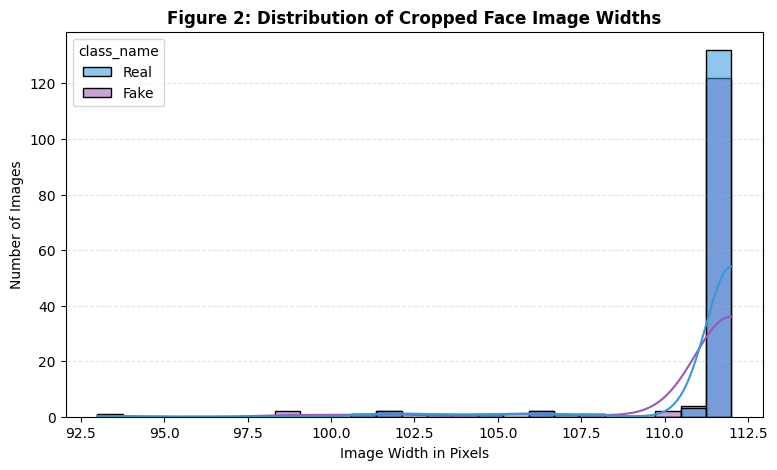

In [14]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=eda_sample,
    x="width",
    hue="class_name",
    bins=25,
    kde=True,
    palette={"Real": "#3498DB", "Fake": "#9B59B6"},
    alpha=0.55
)

plt.title("Figure 2: Distribution of Cropped Face Image Widths", fontweight="bold")
plt.xlabel("Image Width in Pixels")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.show()

# **Image-height distribution**

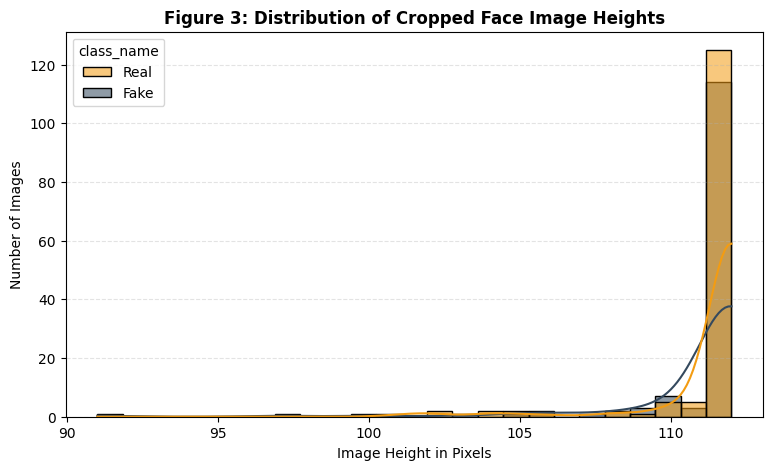

In [15]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=eda_sample,
    x="height",
    hue="class_name",
    bins=25,
    kde=True,
    palette={"Real": "#F39C12", "Fake": "#34495E"},
    alpha=0.55
)

plt.title("Figure 3: Distribution of Cropped Face Image Heights", fontweight="bold")
plt.xlabel("Image Height in Pixels")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.show()

# **Aspect-ratio comparison**

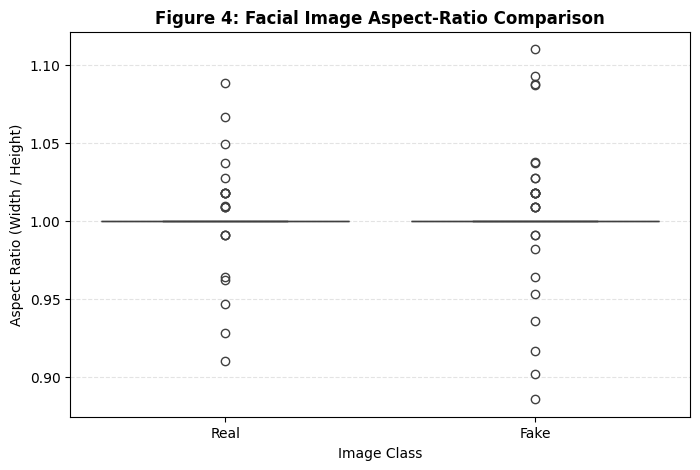

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=eda_sample,
    x="class_name",
    y="aspect_ratio",
    hue="class_name",
    palette={"Real": "#1ABC9C", "Fake": "#E67E22"},
    legend=False
)

plt.title("Figure 4: Facial Image Aspect-Ratio Comparison", fontweight="bold")
plt.xlabel("Image Class")
plt.ylabel("Aspect Ratio (Width / Height)")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.show()

# **Brightness comparison**

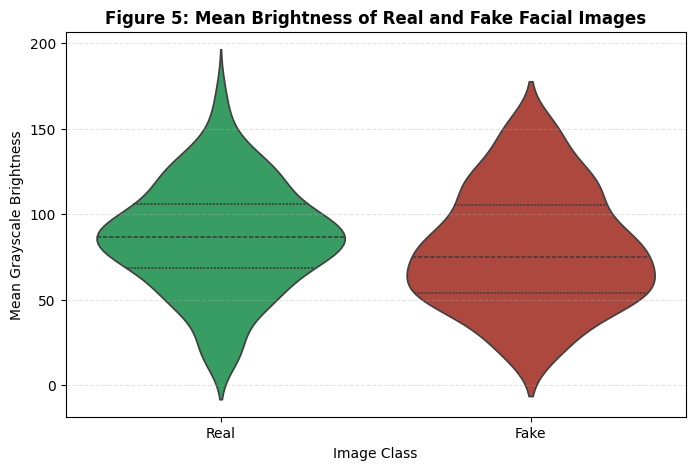

In [17]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=eda_sample,
    x="class_name",
    y="mean_brightness",
    hue="class_name",
    palette={"Real": "#27AE60", "Fake": "#C0392B"},
    legend=False,
    inner="quartile"
)

plt.title("Figure 5: Mean Brightness of Real and Fake Facial Images", fontweight="bold")
plt.xlabel("Image Class")
plt.ylabel("Mean Grayscale Brightness")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.show()

# **Create EDA summary table**

In [18]:
eda_summary = eda_sample.groupby("class_name").agg(
    Image_Count=("image_path", "count"),
    Mean_Width=("width", "mean"),
    Mean_Height=("height", "mean"),
    Mean_Aspect_Ratio=("aspect_ratio", "mean"),
    Mean_Brightness=("mean_brightness", "mean")
).round(2)

eda_summary

,Image_Count,Mean_Width,Mean_Height,Mean_Aspect_Ratio,Mean_Brightness
class_name,,,,,
Fake,138,111.22,111.12,1.0,79.72
Real,145,111.46,111.41,1.0,86.09


In [19]:
eda_summary.to_csv("/content/deepfake_eda_summary.csv")

print("EDA summary table saved as deepfake_eda_summary.csv")

EDA summary table saved as deepfake_eda_summary.csv


# **Apply augmentation and optimise data loading**

In [20]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

# Augmentation is applied only to the training dataset
train_dataset_augmented = train_dataset.map(
    lambda images, labels: (
        data_augmentation(images, training=True),
        labels
    ),
    num_parallel_calls=AUTOTUNE
)

train_dataset_augmented = train_dataset_augmented.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

## **Create the CNN baseline model using ResNet50**

In [21]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

# Pre-trained ResNet50 model
resnet_base = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze pre-trained CNN layers for initial training
resnet_base.trainable = False

cnn_input = Input(shape=(224, 224, 3))

x = tf.keras.applications.resnet50.preprocess_input(cnn_input)
x = resnet_base(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.40)(x)
cnn_output = Dense(1, activation="sigmoid", name="prediction")(x)

cnn_model = Model(
    inputs=cnn_input,
    outputs=cnn_output,
    name="ResNet50_CNN_Deepfake_Detector"
)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

cnn_model.summary()

Model: "ResNet50_CNN_Deepfake_Detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

# **Train the CNN baseline model**

In [22]:
cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.5,
        min_lr=0.000001
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_cnn_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

cnn_history = cnn_model.fit(
    train_dataset_augmented,
    validation_data=validation_dataset,
    epochs=10, # Set epochs back to 10
    callbacks=cnn_callbacks
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 72s 7s/step - accuracy: 0.4573 - loss: 1.1197 - precision: 0.4667 - recall: 0.1321 - val_accuracy: 0.4688 - val_loss: 0.9820 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 6s/step - accuracy: 0.4070 - loss: 1.0895 - precision: 0.3571 - recall: 0.1415 - val_accuracy: 0.5938 - val_loss: 0.8273 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.4121 - loss: 1.0038 - precision: 0.4035 - recall: 0.2170 - val_accuracy: 0.5625 - val_loss: 0.7762 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 7s/step - accuracy: 0.4724 - loss: 0.8609 - precision: 0.5075 - recall: 0.3208 - val_accuracy: 0.5312 - val_loss: 0.7293 - val_precision: 0.3333 - val_recall: 0.0714 - learning_rate: 1.0000e-04
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 81s 

# **Plot CNN training and validation performance**

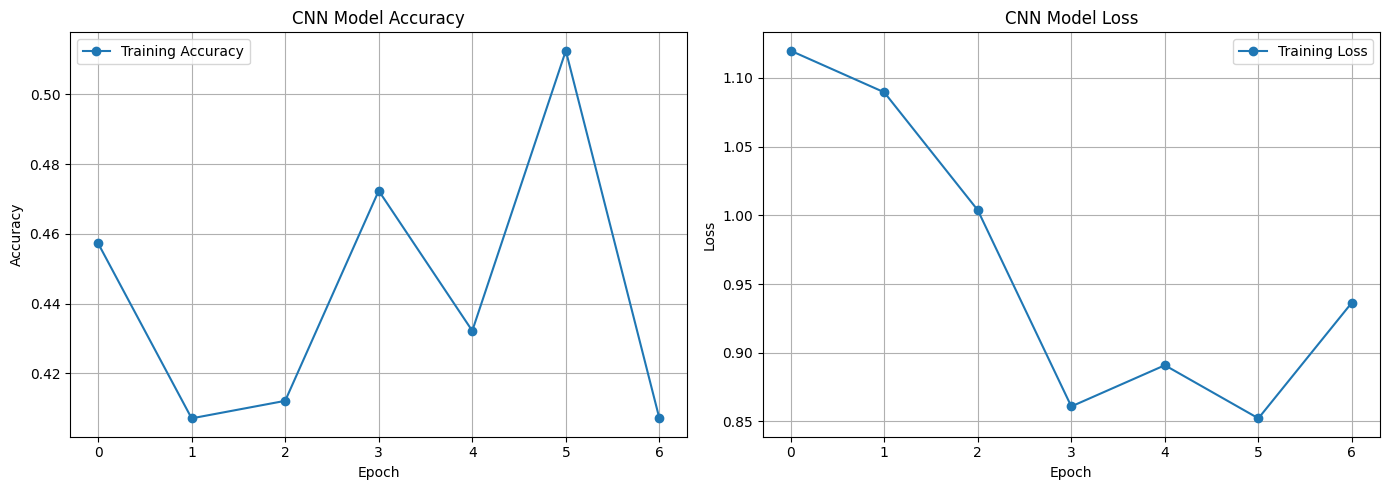

In [23]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Training Accuracy", marker="o")
# Temporarily comment out validation accuracy due to potential data scarcity issues
# plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy", marker="o")
plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Training Loss", marker="o")
# Temporarily comment out validation loss due to potential data scarcity issues
# plt.plot(cnn_history.history["val_loss"], label="Validation Loss", marker="o")
plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Evaluate CNN model**

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Actual labels from test dataset
y_true = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
])

# CNN prediction probabilities and predicted labels
cnn_probabilities = cnn_model.predict(test_dataset).flatten()
cnn_predictions = (cnn_probabilities >= 0.5).astype(int)

cnn_accuracy = accuracy_score(y_true, cnn_predictions)
cnn_precision = precision_score(y_true, cnn_predictions, zero_division=0)
cnn_recall = recall_score(y_true, cnn_predictions, zero_division=0)
cnn_f1 = f1_score(y_true, cnn_predictions, zero_division=0)
cnn_auc = roc_auc_score(y_true, cnn_probabilities)

print("CNN Classification Report\n")
print(classification_report(y_true, cnn_predictions, target_names=["Fake", "Real"]))

print("CNN Accuracy:", round(cnn_accuracy, 4))
print("CNN Precision:", round(cnn_precision, 4))
print("CNN Recall:", round(cnn_recall, 4))
print("CNN F1-Score:", round(cnn_f1, 4))
print("CNN ROC-AUC:", round(cnn_auc, 4))

2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step
CNN Classification Report

              precision    recall  f1-score   support

        Fake       0.49      0.85      0.62        26
        Real       0.43      0.12      0.18        26

    accuracy                           0.48        52
   macro avg       0.46      0.48      0.40        52
weighted avg       0.46      0.48      0.40        52

CNN Accuracy: 0.4808
CNN Precision: 0.4286
CNN Recall: 0.1154
CNN F1-Score: 0.1818
CNN ROC-AUC: 0.5074


# **CNN confusion matrix and ROC curve**

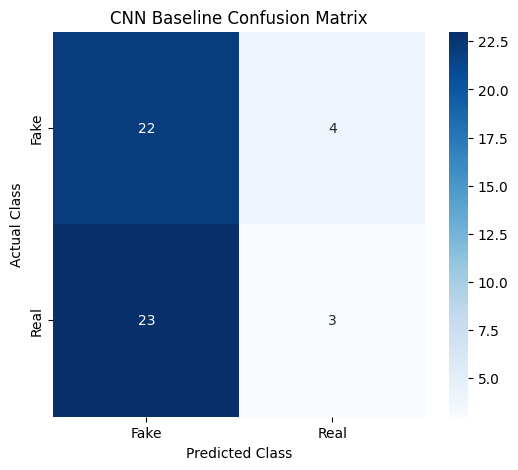

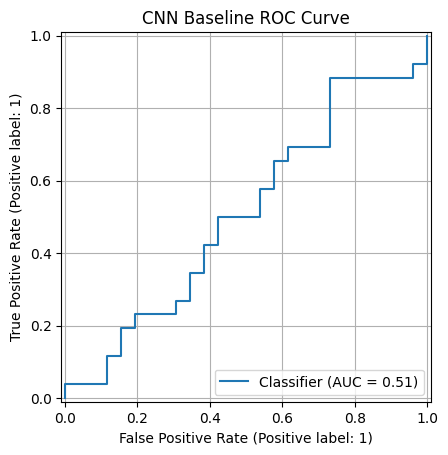

In [25]:
cnn_cm = confusion_matrix(y_true, cnn_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.title("CNN Baseline Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

RocCurveDisplay.from_predictions(y_true, cnn_probabilities)
plt.title("CNN Baseline ROC Curve")
plt.grid(True)
plt.show()

# **Install and create the Vision Transformer model**

In [26]:
!pip -q install tensorflow-hub

In [27]:
import tensorflow_hub as hub
import tensorflow as tf

# Pre-trained ViT model URL
vit_url = "https://tfhub.dev/sayakpaul/vit_b16_fe/1"

# Load the TF Hub module directly
vit_module = hub.load(vit_url)

# Define a custom wrapper function for the module that works with Keras Tensors
@tf.function
def call_vit_module(inputs):
    return vit_module(inputs)

# Rebuild the model using the Keras Functional API
vit_input = tf.keras.Input(shape=(224, 224, 3), dtype=tf.float32)

# First, rescale the input to the expected [0, 1] range for most ViT models
x = tf.keras.layers.Rescaling(1.0 / 255)(vit_input);

# Wrap the loaded module in a Lambda layer to integrate into Keras Functional API
# This bypasses the KerasLayer internal logic that might be causing the issue
x = tf.keras.layers.Lambda(lambda x: call_vit_module(x))(x);

x = tf.keras.layers.Dropout(0.40)(x);
vit_output = tf.keras.layers.Dense(1, activation="sigmoid", name="prediction")(x);

vit_model = tf.keras.Model(
    inputs=vit_input,
    outputs=vit_output,
    name="Vision_Transformer_Deepfake_Detector"
);

vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
);

vit_model.summary()

Model: "Vision_Transformer_Deepfake_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

# **Train the Vision Transformer model**

In [28]:
vit_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.5,
        min_lr=0.000001
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_vit_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

vit_history = vit_model.fit(
    train_dataset_augmented,
    validation_data=validation_dataset,
    epochs=10, # Set epochs back to 10
    callbacks=vit_callbacks
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 271s 30s/step - accuracy: 0.5377 - loss: 1.5134 - precision: 0.5432 - recall: 0.8302 - val_accuracy: 0.4375 - val_loss: 1.4293 - val_precision: 0.4643 - val_recall: 0.8125 - learning_rate: 1.0000e-04
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 178s 25s/step - accuracy: 0.5025 - loss: 1.5710 - precision: 0.5223 - recall: 0.7736 - val_accuracy: 0.4062 - val_loss: 1.7149 - val_precision: 0.4138 - val_recall: 0.8571 - learning_rate: 1.0000e-04
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 200s 29s/step - accuracy: 0.5477 - loss: 1.3555 - precision: 0.5513 - recall: 0.8113 - val_accuracy: 0.3125 - val_loss: 1.5844 - val_precision: 0.3333 - val_recall: 0.5714 - learning_rate: 1.0000e-04
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 177s 25s/step - accuracy: 0.4673 - loss: 1.3783 - precision: 0.5000 - recall: 0.6698 - val_accuracy: 0.5625 - val_loss: 0.9192 - val_precision: 0.5769 - val_recall: 0.8333 - learning_rate: 5.0000e-05
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 219s 28s/step - accu

# **Plot Vision Transformer results**

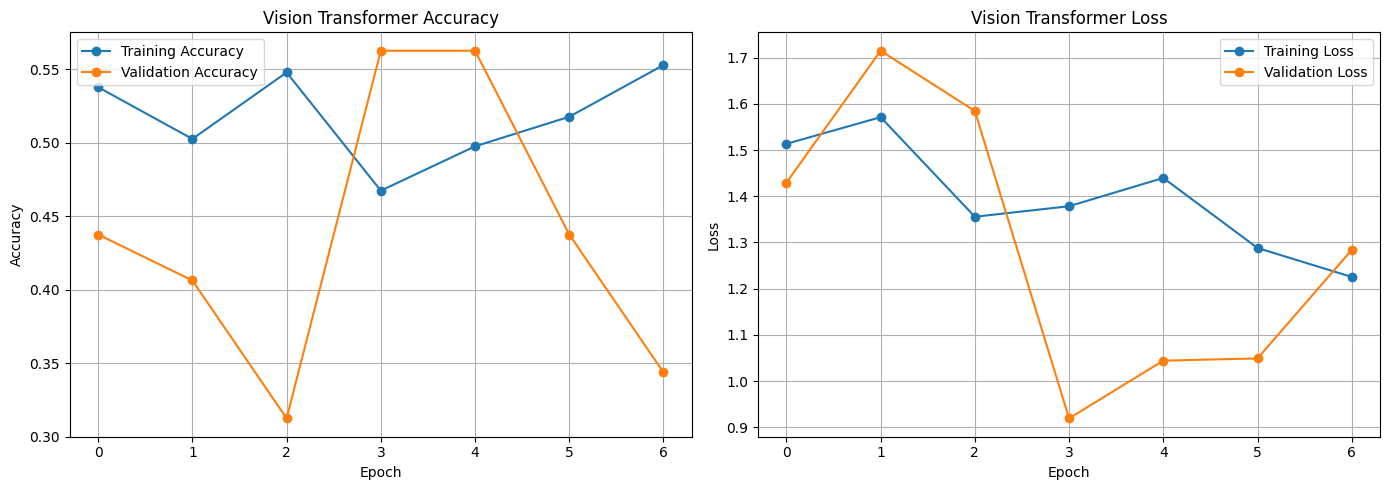

In [29]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(vit_history.history["accuracy"], label="Training Accuracy", marker="o")
plt.plot(vit_history.history["val_accuracy"], label="Validation Accuracy", marker="o")
plt.title("Vision Transformer Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(vit_history.history["loss"], label="Training Loss", marker="o")
plt.plot(vit_history.history["val_loss"], label="Validation Loss", marker="o")
plt.title("Vision Transformer Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Evaluate Vision Transformer model**

In [30]:
vit_probabilities = vit_model.predict(test_dataset).flatten()
vit_predictions = (vit_probabilities >= 0.5).astype(int)

vit_accuracy = accuracy_score(y_true, vit_predictions)
vit_precision = precision_score(y_true, vit_predictions, zero_division=0)
vit_recall = recall_score(y_true, vit_predictions, zero_division=0)
vit_f1 = f1_score(y_true, vit_predictions, zero_division=0)
vit_auc = roc_auc_score(y_true, vit_probabilities)

print("Vision Transformer Classification Report\n")
print(classification_report(y_true, vit_predictions, target_names=["Fake", "Real"]))

print("Vision Transformer Accuracy:", round(vit_accuracy, 4))
print("Vision Transformer Precision:", round(vit_precision, 4))
print("Vision Transformer Recall:", round(vit_recall, 4))
print("Vision Transformer F1-Score:", round(vit_f1, 4))
print("Vision Transformer ROC-AUC:", round(vit_auc, 4))

2/2 ━━━━━━━━━━━━━━━━━━━━ 48s 23s/step
Vision Transformer Classification Report

              precision    recall  f1-score   support

        Fake       0.33      0.08      0.12        26
        Real       0.48      0.85      0.61        26

    accuracy                           0.46        52
   macro avg       0.41      0.46      0.37        52
weighted avg       0.41      0.46      0.37        52

Vision Transformer Accuracy: 0.4615
Vision Transformer Precision: 0.4783
Vision Transformer Recall: 0.8462
Vision Transformer F1-Score: 0.6111
Vision Transformer ROC-AUC: 0.5621


# **Vision Transformer confusion matrix and ROC curve**

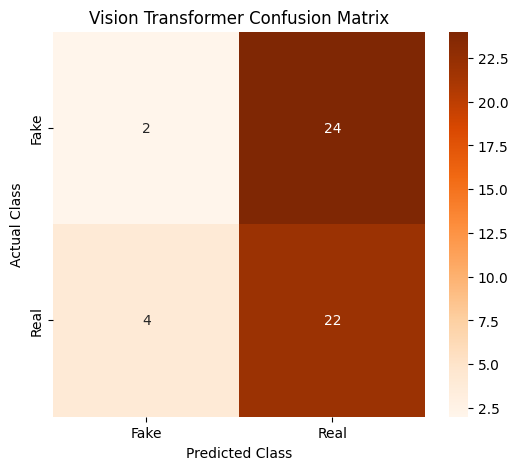

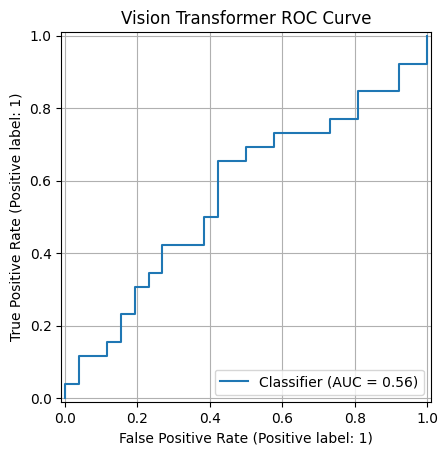

In [31]:
vit_cm = confusion_matrix(y_true, vit_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    vit_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.title("Vision Transformer Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

RocCurveDisplay.from_predictions(y_true, vit_probabilities)
plt.title("Vision Transformer ROC Curve")
plt.grid(True)
plt.show()

# **Create final model-comparison table**

In [32]:
comparison_table = pd.DataFrame({
    "Model": ["ResNet50 CNN Baseline", "Vision Transformer with Attention"],
    "Accuracy": [cnn_accuracy, vit_accuracy],
    "Precision": [cnn_precision, vit_precision],
    "Recall": [cnn_recall, vit_recall],
    "F1-Score": [cnn_f1, vit_f1],
    "ROC-AUC": [cnn_auc, vit_auc]
})

comparison_table = comparison_table.round(4)
comparison_table

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,ResNet50 CNN Baseline,0.4808,0.4286,0.1154,0.1818,0.5074
1,Vision Transformer with Attention,0.4615,0.4783,0.8462,0.6111,0.5621


In [33]:
comparison_table.to_csv(
    "/content/deepfake_model_comparison_results.csv",
    index=False
)

print("Final comparison table saved successfully.")

Final comparison table saved successfully.


# **Plot the model comparison**

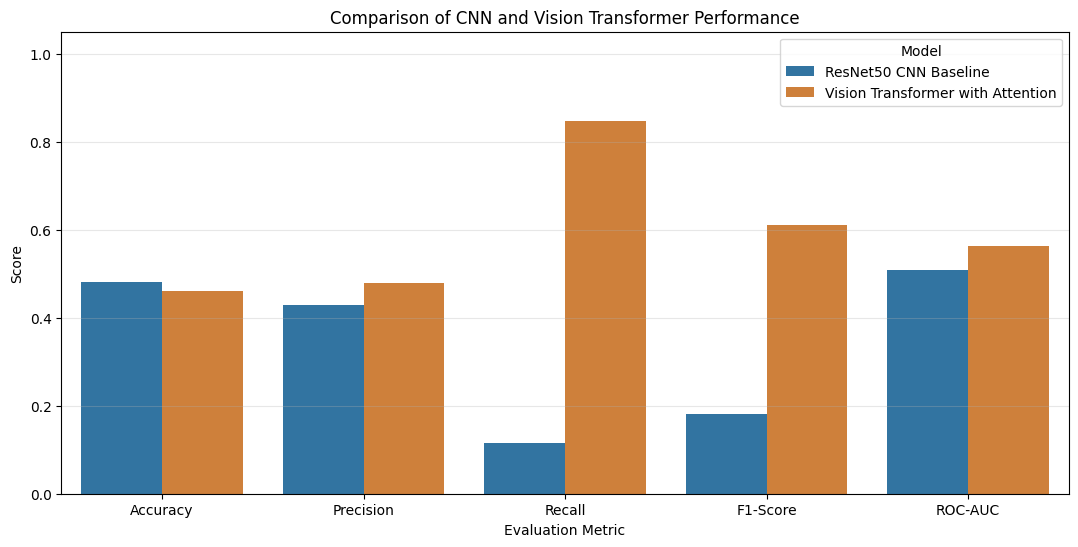

In [34]:
plot_table = comparison_table.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(13, 6))
sns.barplot(
    data=plot_table,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#1F77B4", "#E67E22"]
)

plt.ylim(0, 1.05)
plt.title("Comparison of CNN and Vision Transformer Performance")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.3)
plt.show()

# **Save both trained models**

In [35]:
cnn_model.save("/content/final_cnn_deepfake_detector.keras")
vit_model.save("/content/final_vit_deepfake_detector.keras")

print("CNN and Vision Transformer models saved successfully.")

CNN and Vision Transformer models saved successfully.


# **Combined training-accuracy comparison**

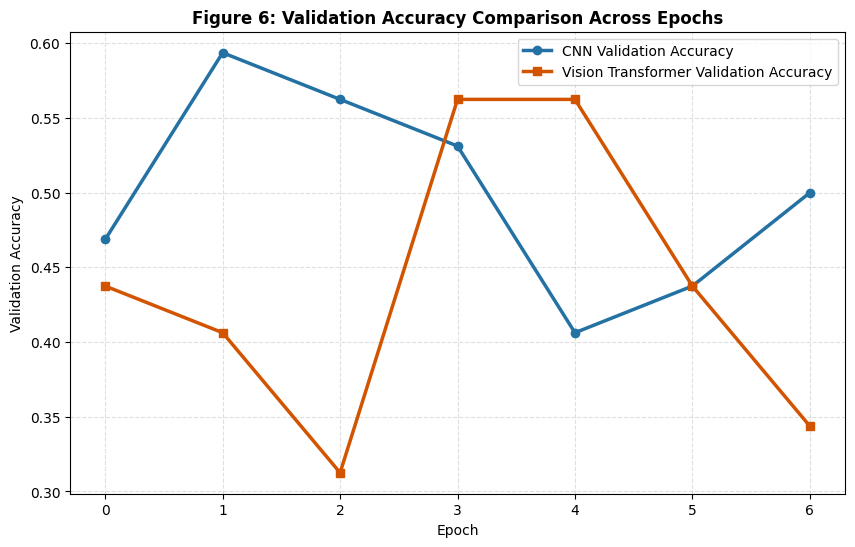

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    cnn_history.history["val_accuracy"],
    marker="o",
    linewidth=2.5,
    color="#2471A3",
    label="CNN Validation Accuracy"
)

plt.plot(
    vit_history.history["val_accuracy"],
    marker="s",
    linewidth=2.5,
    color="#D35400",
    label="Vision Transformer Validation Accuracy"
)

plt.title("Figure 6: Validation Accuracy Comparison Across Epochs", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# **Combined training-loss comparison**

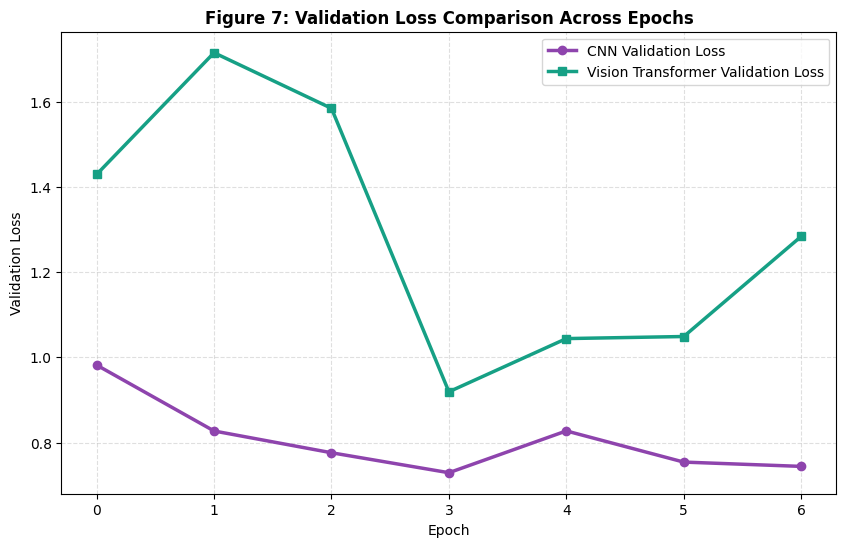

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    cnn_history.history["val_loss"],
    marker="o",
    linewidth=2.5,
    color="#8E44AD",
    label="CNN Validation Loss"
)

plt.plot(
    vit_history.history["val_loss"],
    marker="s",
    linewidth=2.5,
    color="#16A085",
    label="Vision Transformer Validation Loss"
)

plt.title("Figure 7: Validation Loss Comparison Across Epochs", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# **Combined ROC-AUC curve**

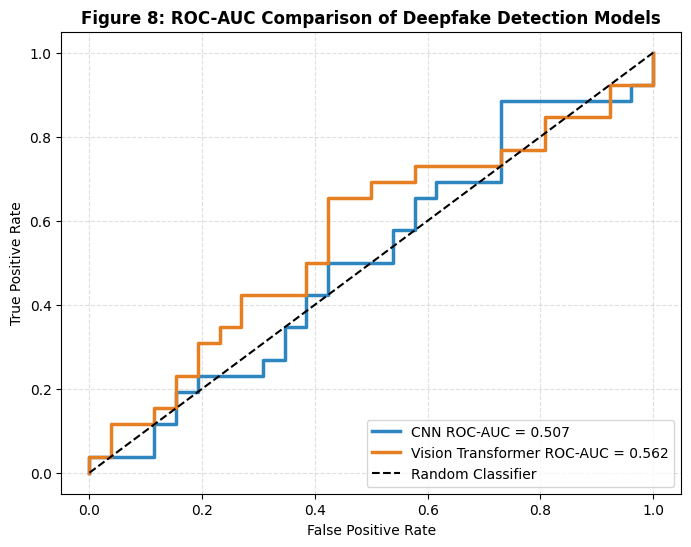

In [38]:
from sklearn.metrics import roc_curve, auc

cnn_fpr, cnn_tpr, _ = roc_curve(y_true, cnn_probabilities)
vit_fpr, vit_tpr, _ = roc_curve(y_true, vit_probabilities)

cnn_roc_auc = auc(cnn_fpr, cnn_tpr)
vit_roc_auc = auc(vit_fpr, vit_tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    cnn_fpr,
    cnn_tpr,
    color="#2E86C1",
    linewidth=2.5,
    label=f"CNN ROC-AUC = {cnn_roc_auc:.3f}"
)

plt.plot(
    vit_fpr,
    vit_tpr,
    color="#E67E22",
    linewidth=2.5,
    label=f"Vision Transformer ROC-AUC = {vit_roc_auc:.3f}"
)

plt.plot([0, 1], [0, 1], color="black", linestyle="--", label="Random Classifier")

plt.title("Figure 8: ROC-AUC Comparison of Deepfake Detection Models", fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# **Precision–recall curve comparison**

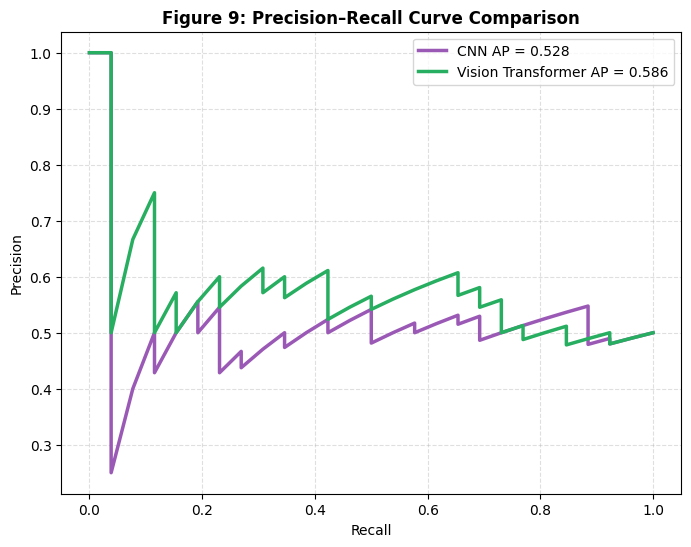

In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score

cnn_precision_curve, cnn_recall_curve, _ = precision_recall_curve(
    y_true,
    cnn_probabilities
)

vit_precision_curve, vit_recall_curve, _ = precision_recall_curve(
    y_true,
    vit_probabilities
)

cnn_average_precision = average_precision_score(y_true, cnn_probabilities)
vit_average_precision = average_precision_score(y_true, vit_probabilities)

plt.figure(figsize=(8, 6))

plt.plot(
    cnn_recall_curve,
    cnn_precision_curve,
    color="#9B59B6",
    linewidth=2.5,
    label=f"CNN AP = {cnn_average_precision:.3f}"
)

plt.plot(
    vit_recall_curve,
    vit_precision_curve,
    color="#27AE60",
    linewidth=2.5,
    label=f"Vision Transformer AP = {vit_average_precision:.3f}"
)

plt.title("Figure 9: Precision–Recall Curve Comparison", fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# **Prediction-probability distribution**

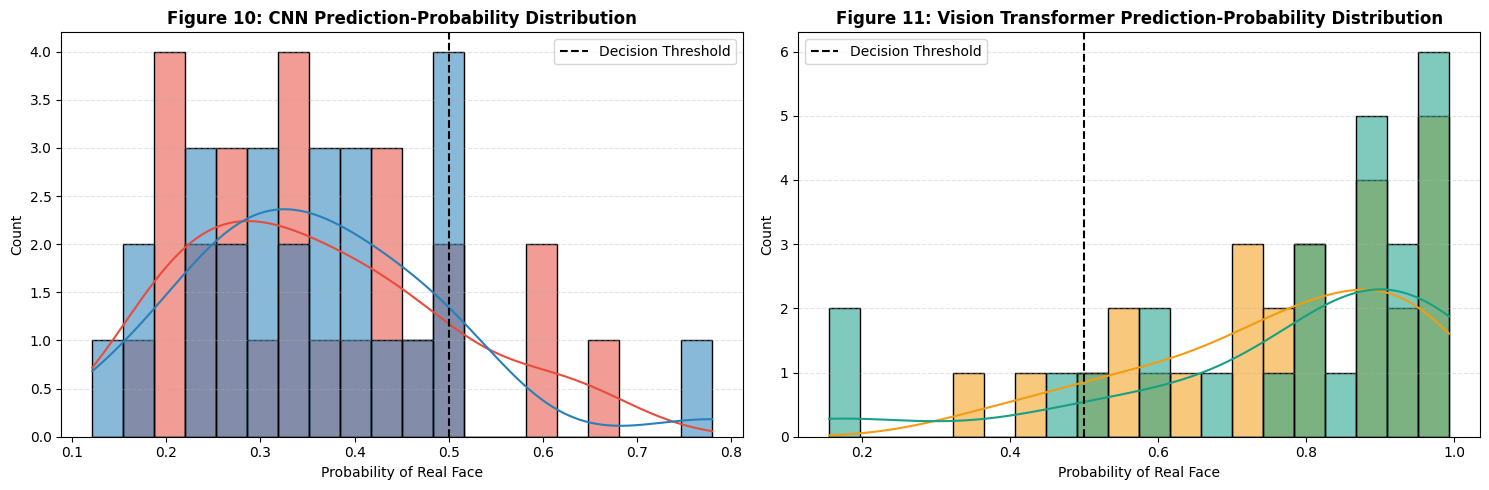

In [40]:
prediction_df = pd.DataFrame({
    "Actual Class": np.where(y_true == 1, "Real", "Fake"),
    "CNN Probability of Real": cnn_probabilities,
    "Vision Transformer Probability of Real": vit_probabilities
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=prediction_df,
    x="CNN Probability of Real",
    hue="Actual Class",
    bins=20,
    kde=True,
    palette={"Real": "#2980B9", "Fake": "#E74C3C"},
    alpha=0.55,
    ax=axes[0]
)

axes[0].axvline(0.5, color="black", linestyle="--", label="Decision Threshold")
axes[0].set_title("Figure 10: CNN Prediction-Probability Distribution", fontweight="bold")
axes[0].set_xlabel("Probability of Real Face")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.35)

sns.histplot(
    data=prediction_df,
    x="Vision Transformer Probability of Real",
    hue="Actual Class",
    bins=20,
    kde=True,
    palette={"Real": "#16A085", "Fake": "#F39C12"},
    alpha=0.55,
    ax=axes[1]
)

axes[1].axvline(0.5, color="black", linestyle="--", label="Decision Threshold")
axes[1].set_title("Figure 11: Vision Transformer Prediction-Probability Distribution", fontweight="bold")
axes[1].set_xlabel("Probability of Real Face")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

# **Metrics comparison heatmap**

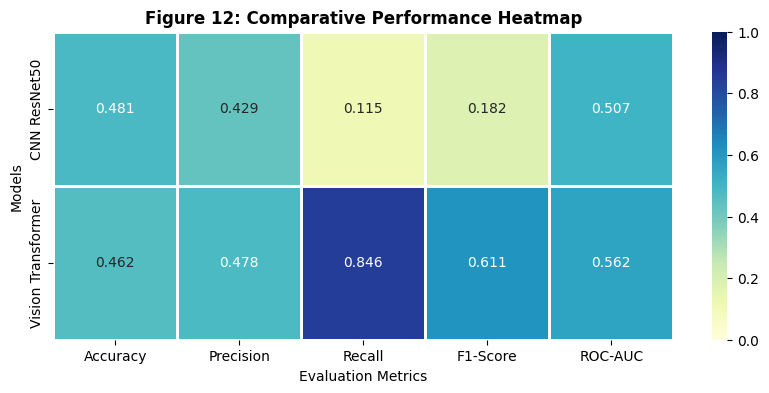

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
CNN ResNet50,0.4808,0.4286,0.1154,0.1818,0.5074
Vision Transformer,0.4615,0.4783,0.8462,0.6111,0.5621


In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metrics_comparison = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_true, cnn_predictions),
        accuracy_score(y_true, vit_predictions)
    ],
    "Precision": [
        precision_score(y_true, cnn_predictions, zero_division=0),
        precision_score(y_true, vit_predictions, zero_division=0)
    ],
    "Recall": [
        recall_score(y_true, cnn_predictions, zero_division=0),
        recall_score(y_true, vit_predictions, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_true, cnn_predictions, zero_division=0),
        f1_score(y_true, vit_predictions, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_true, cnn_probabilities),
        roc_auc_score(y_true, vit_probabilities)
    ]
}, index=["CNN ResNet50", "Vision Transformer"])

plt.figure(figsize=(10, 4))

sns.heatmap(
    metrics_comparison,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    vmin=0,
    vmax=1
)

plt.title("Figure 12: Comparative Performance Heatmap", fontweight="bold")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Models")
plt.show()

display(metrics_comparison.round(4))

# **Show correctly and incorrectly predicted images**

Incorrect Vision Transformer predictions: 27


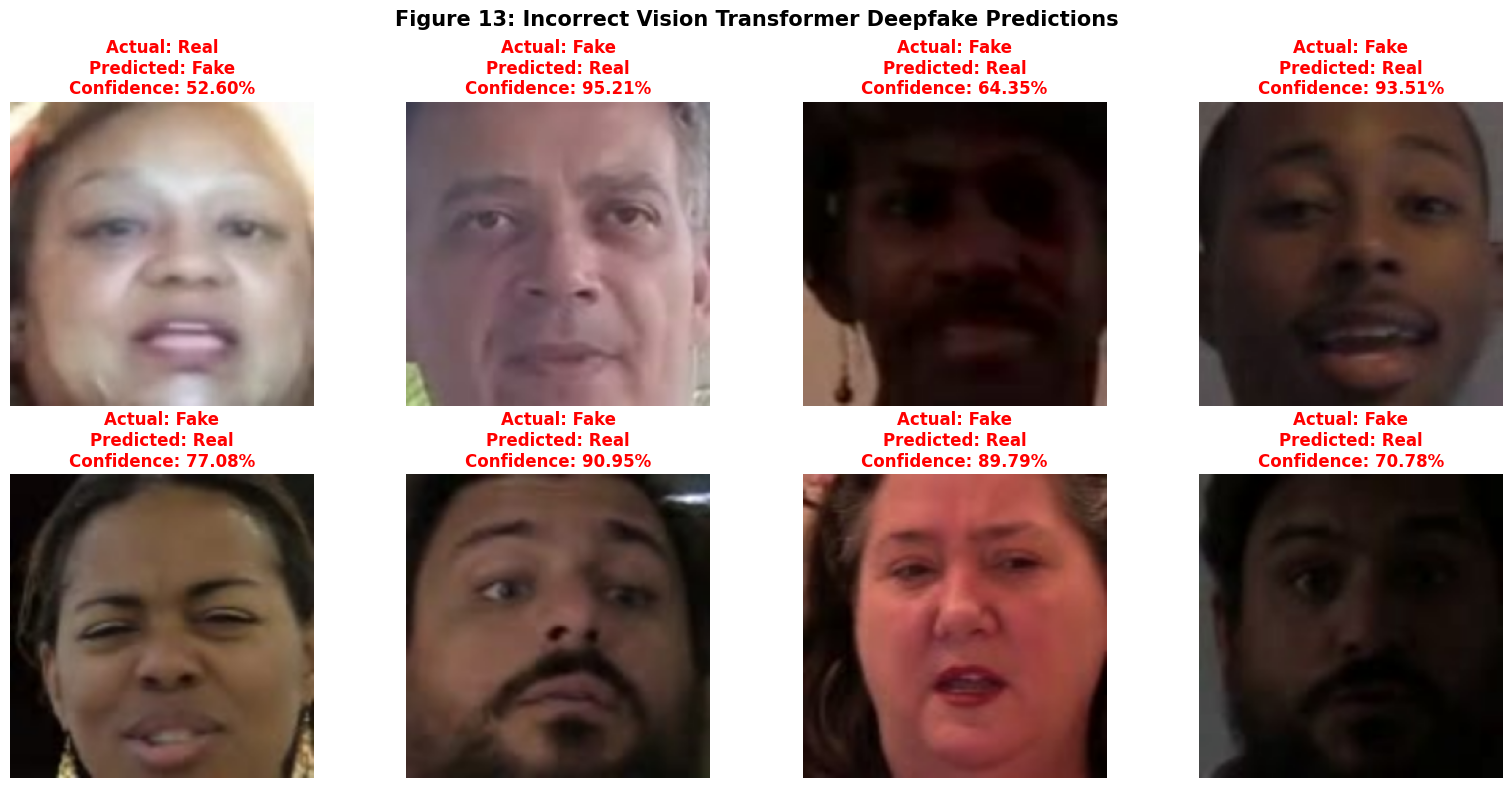

In [42]:
# Get images and labels from test dataset
test_images = np.concatenate([images.numpy() for images, labels in test_dataset])
test_labels = np.concatenate([labels.numpy().flatten() for images, labels in test_dataset])

# Ensure the number of images equals the number of predictions
test_images = test_images[:len(vit_predictions)]
test_labels = test_labels[:len(vit_predictions)]

incorrect_indices = np.where(test_labels != vit_predictions)[0]

print("Incorrect Vision Transformer predictions:", len(incorrect_indices))

if len(incorrect_indices) > 0:
    selected_indices = np.random.choice(
        incorrect_indices,
        size=min(8, len(incorrect_indices)),
        replace=False
    )

    plt.figure(figsize=(16, 8))

    for position, index in enumerate(selected_indices):
        plt.subplot(2, 4, position + 1)

        image = test_images[index].astype("uint8")
        actual = "Real" if test_labels[index] == 1 else "Fake"
        predicted = "Real" if vit_predictions[index] == 1 else "Fake"
        confidence = vit_probabilities[index] if vit_predictions[index] == 1 else 1 - vit_probabilities[index]

        plt.imshow(image)
        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}\nConfidence: {confidence:.2%}",
            color="red",
            fontweight="bold"
        )
        plt.axis("off")

    plt.suptitle(
        "Figure 13: Incorrect Vision Transformer Deepfake Predictions",
        fontsize=15,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()
else:
    print("No incorrect predictions were found.")